# **Développez une preuve de concept : faut-il remplacer un modèle BERT éprouvé par un Transformer plus récent ?**



---



## Sommaire du pipeline expérimental


---



1. **Contexte et objectif**
    - Comparatifs des modèles BERT et DeBERTa-v3
    - Objectif de l'exercice et résultat attendu

2. **Chargement et exploration du dataset**  
   - Import du dataset `tweets_16k.parquet`  
   - Vérification des dimensions, des colonnes et du type de données  

3. **Préparation des labels et validation du dataset**  
   - Remapping des labels (`0 / 4` → `0 / 1`)  
   - Vérification de l’équilibre des classes  

4. **Découpage du dataset et préparation pour Transformer**  
   - Séparation en ensembles d’entraînement, de validation et de test  
   - Conservation de l’équilibre des classes et reproductibilité
   - Conversion des DataFrames en `Dataset` Hugging Face  
      
5. **Implémentation et entraînement de la baseline**
    - Tokenisation des textes  
   - Formatage des données pour l’entraînement PyTorch
   - Mise en place du modèle BERT  
   - Entraînement sur l’ensemble d’apprentissage  
   - Évaluation sur les ensembles de validation et de test  

6. **Implémentation du modèle récent**  
   - Mise en place du modèle DeBERTa-v3  
   - Ajustement raisonné des hyperparamètres  
   - Entraînement et évaluation  

7. **Comparaison des performances**  
   - Analyse des métriques (F1-score, précision, rappel)  
   - Comparaison des temps d’entraînement et de la complexité  

8. **Optimisation et choix de la métrique cible**  
   - Analyse du seuil de décision  
   - Discussion autour des compromis performance / robustesse  

9. **Interprétabilité du modèle**  
   - Interprétabilité globale  
   - Interprétabilité locale sur des exemples de prédictions  

10. **Discussion et conclusion**  
    - Bilan des performances  
    - Limites de l’approche  
    - Perspectives d’amélioration


## 1. Contexte et positionnement des modèles


---



### Comparatif historique des modèles

Le modèle **BERT (Bidirectional Encoder Representations from Transformers)** a été introduit par Google en **2018**. Il a marqué une rupture majeure dans le traitement du langage naturel en proposant une représentation bidirectionnelle du texte grâce au mécanisme d’auto-attention des Transformers.  
Depuis, BERT est devenu une **baseline de référence** dans de nombreuses tâches NLP (classification, NER, QA), et reste largement utilisé en production du fait de sa stabilité, de sa maturité et de sa documentation abondante.

Le modèle **DeBERTa (Decoding-enhanced BERT with Disentangled Attention)** a été proposé par Microsoft en **2021**, soit environ **3 ans après BERT**.  
La version **DeBERTa-v3** correspond à une itération plus récente, intégrant des améliorations supplémentaires dans la phase de pré-entraînement, notamment via une stratégie de *pretraining plus efficace et plus robuste*.  
DeBERTa-v3 s’inscrit ainsi dans la continuité des travaux visant à dépasser les limites de BERT, tout en conservant une architecture de type Transformer compatible avec les usages existants.

En résumé :
- BERT : modèle de référence, mature, éprouvé (2018)
- DeBERTa-v3 : modèle plus récent, optimisé, issu de travaux de recherche récents (2021)

---

### Comparatif de fonctionnement et similitudes entre les modèles

BERT et DeBERTa-v3 reposent tous deux sur :
- une architecture **Transformer encoder**
- un mécanisme d’**auto-attention**
- un **fine-tuning supervisé** pour les tâches de classification
- une tokenisation sous-mots (WordPiece ou équivalent)

Ils sont donc **directement comparables** sur un même jeu de données, avec un pipeline expérimental identique.

La différence principale réside dans la manière dont l’information est représentée et exploitée :

- **BERT** encode conjointement le contenu lexical des tokens et leur position dans la phrase.
- **DeBERTa** introduit une **attention désentrelacée (disentangled attention)**, séparant explicitement :
  - l’information de contenu des tokens,
  - l’information de position relative.

Cette séparation permet au modèle de :
- mieux capturer les relations sémantiques fines,
- mieux gérer l’ordre des mots,
- améliorer la généralisation, notamment sur des textes courts et informels.

Dans le cas de tweets ou de phrases courtes :
- la structure syntaxique est souvent instable,
- le contexte est réduit,
- chaque token porte une information forte.

DeBERTa est donc **théoriquement mieux armé** pour exploiter ce type de données, là où BERT peut être limité par une représentation plus entremêlée du contenu et de la position.

---

### Objectif de l’exercice et résultat attendu

L’objectif de cet exercice est de mener une **preuve de concept (POC)** visant à évaluer si un modèle plus récent (**DeBERTa-v3**) permet d’améliorer significativement les performances d’un modèle de référence (**BERT**) sur une tâche de **classification binaire de textes courts**.

Pour garantir la validité de la comparaison :
- le **jeu de données est identique**,
- le **split train / validation / test est figé**,
- les **métriques d’évaluation sont strictement les mêmes**,
- le protocole expérimental est maintenu constant.

Le résultat attendu n’est pas nécessairement une amélioration spectaculaire, mais :
- une **analyse objective du gain de performance** (notamment en F1-score),
- une **mise en perspective du coût computationnel** et de la complexité,
- une **aide à la décision** quant à l’intérêt réel de migrer vers un modèle plus récent dans un contexte de production ou de prototypage.

Ce travail s’inscrit donc dans une démarche d’ingénierie pragmatique :  
**évaluer le rapport bénéfices / contraintes d’un modèle récent par rapport à une baseline éprouvée.**


## 2. Chargement et exploration du dataset


---



In [1]:
import sys, os, platform
from datetime import datetime

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Working dir:", os.getcwd())
print("Now:", datetime.now())


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
Working dir: /content
Now: 2025-12-30 16:26:23.715560


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/INGENIEUR_IA/P9_Proof_of_Concept"

DATA_DIR = os.path.join(BASE_DIR, "data")
DATA_RAW = os.path.join(DATA_DIR, "raw")
DATA_PROC = os.path.join(DATA_DIR, "processed")

MODELS_DIR = os.path.join(BASE_DIR, "models")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")

for p in [DATA_RAW, DATA_PROC, MODELS_DIR, REPORTS_DIR]:
    os.makedirs(p, exist_ok=True)

BASE_DIR



'/content/drive/MyDrive/INGENIEUR_IA/P9_Proof_of_Concept'

Dans ce projet, le dataset `tweets_16k.parquet` constitue la donnée brute d’entrée (`raw`) de la preuve de concept. Le dataset complet n’a pas été retenu afin de maîtriser les coûts de calcul et de concentrer l’analyse sur la comparaison des modèles.

In [4]:
import pandas as pd

DATASET_PATH = os.path.join(DATA_RAW, "tweets_16k.parquet")

df = pd.read_parquet(DATASET_PATH)

print("Shape :", df.shape)
print("\nColonnes :", df.columns.tolist())
display(df.dtypes)
display(df.head())


Shape : (16000, 3)

Colonnes : ['label', 'text', 'len']


,0
label,int64
text,object
len,int64


,label,text,len
0,0,@MartynGray but you are taken,30
1,0,Watching Diary of the Dead and doing some stud...,75
2,0,@Wardere isn't he quitting nov. 1st,36
3,0,Hiiyah wats everyone doin? talk 2 me im so bor...,125
4,0,another point for claudette. internet is reall...,55


**Aperçu**  
Ce dataset contient :
- des **tweets courts**,  
- du **langage informel** et
- une **classification binaire** déguiséé (0/4).  

Il est parfaitement adapté à :
- **BERT** en tant que baseline,
- **DeBERTa-v3** en tant que modèle plus récent.

**Avant de modéliser, nous devons traiter 3 points critiques :**

1.   les **labels**, ils doivent être ramenés à **`0/1`**, conformément aux attentes des modèles de classification supervisée.
2.   la colonne **`len`**, hormis informative, est inutile car **elle n'est pas utilisée** par les `Transformers`.
3. le **prétraitement du texte** ne doit pas subir de nettoyage agressif (suppression de stopwords, stemming, lemmatisation) car le **`tokenizer` pré-entraîné** fera le travail. Associé aux modèles `Transformer`, il est responsable de la gestion des sous-mots et de la représentation linguistique.

## 3. Préparation des labels et validation du dataset


---



**Objectif**
Transformer une classification “déguisée” en binaire standard
sans perdre d’information
de façon lisible et traçable

In [5]:
# Vérification des labels avant transformation
df["label"].value_counts().sort_index()

,count
label,
0,8000
4,8000


In [6]:
# Remapping des labels : 0 -> 0 (négatif), 4 -> 1 (positif)
df["label"] = df["label"].map({0: 0, 4: 1})

# Vérification après transformation
df["label"].value_counts().sort_index()


,count
label,
0,8000
1,8000


## Équilibre des classes

Après remapping des labels, le dataset est **parfaitement équilibré** :

- Classe `0` (négatif) : 8 000 observations  
- Classe `1` (positif) : 8 000 observations  

Aucune technique de rééquilibrage (sur- ou sous-échantillonnage) n’est nécessaire.  
Ce point est particulièrement important pour l’entraînement de modèles Transformer, pour lesquels un jeu de données équilibré permet une évaluation plus fiable et une interprétation plus directe des métriques de performance.

Dans la suite, le dataset sera divisé en **ensembles d’entraînement, de validation et de test** à l’aide d’un **split fixe**, afin de garantir la reproductibilité des expériences et une comparaison équitable entre les modèles.


## 4. Découpage du dataset et préparation pour Transformer

---



Le dataset est divisé en **ensembles d’entraînement, de validation et de test** à l’aide d’un **split fixe**, afin de garantir la reproductibilité des expériences et une comparaison équitable entre les modèles.

Le split sera effectué ainsi :
80 % train
10 % validation
10 % test

In [7]:
from sklearn.model_selection import train_test_split

# Séparation train / temp (val + test)
df_train, df_temp = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# Séparation validation / test
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp["label"],
    random_state=42
)

# Vérification des tailles
print("Train :", df_train.shape)
print("Validation :", df_val.shape)
print("Test :", df_test.shape)

# Vérification de l'équilibre des classes
print("\nRépartition des labels :")
print("Train:\n", df_train["label"].value_counts())
print("Validation:\n", df_val["label"].value_counts())
print("Test:\n", df_test["label"].value_counts())


Train : (12800, 3)
Validation : (1600, 3)
Test : (1600, 3)

Répartition des labels :
Train:
 label
0    6400
1    6400
Name: count, dtype: int64
Validation:
 label
0    800
1    800
Name: count, dtype: int64
Test:
 label
0    800
1    800
Name: count, dtype: int64


In [8]:
# Conversion des DataFrames en Dataset Hugging Face

from datasets import Dataset

train_dataset = Dataset.from_pandas(df_train[["text", "label"]])
val_dataset   = Dataset.from_pandas(df_val[["text", "label"]])
test_dataset  = Dataset.from_pandas(df_test[["text", "label"]])


## 5. Implémentation et entraînement de la baseline


---

**Objectif**  
Cette étape consiste à entraîner un modèle **BERT** en tant que baseline de référence.
Ce modèle servira de point de comparaison avec un modèle plus récent (`DeBERTa-v3`), dans un protocole expérimental strictement identique.


**Pré-traitement**  
Avant l’entraînement du modèle, les **données textuelles** doivent être transformées en **représentations numériques** compréhensibles par le modèle `Transformer`.  
Cette étape repose sur l’utilisation du `tokenizer` associé au modèle, qui se charge de **convertir le texte en séquences de tokens**, tout en gérant le **padding** et la **troncature**.

In [9]:
# Chargement du tokenizer BERT (baseline)

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [10]:
# Tokenisation
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [11]:
# Application de la tokenisation
train_dataset_bert = train_dataset.map(tokenize_function, batched=True)
val_dataset_bert   = val_dataset.map(tokenize_function, batched=True)
test_dataset_bert  = test_dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/12800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Les datasets sont maintenant formatés pour `PyTorch` afin de garantir la compatibilité avec les modèles `Transformer`, qui attendent des tenseurs `PyTorch` pour l’entraînement et l’inférence.

In [12]:
# Formatage pour PyTorch
train_dataset_bert.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset_bert.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset_bert.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


In [13]:
# Sanity check

train_dataset_bert[0]

{'label': tensor(0),
 'input_ids': tensor([  101,  2498,  2004,  1045,  2572,  6069,  2079, 19453,  1024,  2381,
          1010,  2128,  1998,  2394,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,   

Le sanity check est validé :
- le format est bien en `PyTorch` avec les `tensor` pour chaque élément : `label`, `input_ids` et `attention_mask`.
- le label contient bien une valeur binaire (`0` ou `1`)
- 101 sera utilisé comme [CLS](classification token): c'est ce token qui permet au modèle de décider "positif" ou "négatif".
- 102 est ici le [SEP](separator token): il marque la fin de la phrase.
- toutes les valeurs `0` dans `input_ids`, représentent le padding: elles sont nécessaires car **toutes les séquences doivent avoir la même longueur** dans les modèles `Transformer`.
- les valeurs d'`attention_mask` viennent jouer un rôle de securité par rapport au point précédent: la valeur **`1` correspond à un token réel** et la valeur **`0` à du padding**.
*Nous avons fixé une longueur maximale du tweet à 128 tokens.*


Nous sommes donc prêts à charger le modèle.

In [14]:
# Chargement du modèle BERT pour classification binaire

from transformers import AutoModelForSequenceClassification

model_bert = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Les `TrainingArguments` choisis sont en ligne avec les standards `BERT` et la taille des datasets:
- `2e-5` pour le `learning rate`,
- `4 epochs` suffiront pour une bonne convergence,
- `batch_size=32`,
- `fp16=True` pour vitesse et mémoire`
- et le `f1` score comme métrique centrale pour une classifiction binaire.

In [15]:
# Paramètres d'entraînement (TrainingArguments)

from transformers import TrainingArguments

training_args_bert = TrainingArguments(
    output_dir="./results_bert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    logging_dir="./logs_bert",
    logging_steps=100,
    report_to="none",
    seed=42
)

In [16]:
# Définition des métriques

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [17]:
# Entraînement avec Trainer

from transformers import Trainer

trainer_bert = Trainer(
    model=model_bert,
    args=training_args_bert,
    train_dataset=train_dataset_bert,
    eval_dataset=val_dataset_bert,
    compute_metrics=compute_metrics
)

# Lancement de l'entraînement
trainer_bert.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.422500,0.422271,0.813750,0.848611,0.763750,0.803947
2,0.314300,0.418073,0.826250,0.808511,0.855000,0.831106
3,0.212400,0.468525,0.831250,0.850529,0.803750,0.826478
4,0.132500,0.561818,0.825000,0.827456,0.821250,0.824341


TrainOutput(global_step=1600, training_loss=0.28392090439796447, metrics={'train_runtime': 88.7879, 'train_samples_per_second': 576.655, 'train_steps_per_second': 18.02, 'total_flos': 3367821508608000.0, 'train_loss': 0.28392090439796447, 'epoch': 4.0})

In [18]:
# Évaluation finale sur le jeu de test

test_results_bert = trainer_bert.evaluate(test_dataset_bert)

test_results_bert


{'eval_loss': 0.4079694449901581,
 'eval_accuracy': 0.833125,
 'eval_precision': 0.8277982779827798,
 'eval_recall': 0.84125,
 'eval_f1': 0.8344699318040918,
 'eval_runtime': 0.8115,
 'eval_samples_per_second': 1971.777,
 'eval_steps_per_second': 61.618,
 'epoch': 4.0}

Afin de visualiser les résultats, **4 courbes indispensables**:
- la **`loss`** qui évalue l'**apprentissage** du modèle
- la **`F1-score`** qui évalue la **performance** du modèle
- la **`ROC` (Receiver Operating Characteristic)** qui évalue la capacité de **discrimination** du modèle.
- la **`Precision-Recall`** qui évalue les FP (faux positifs) et les FN (faux négatifs).

In [19]:
# Extraction des logs Trainer

import pandas as pd

def get_trainer_logs(trainer):
    """
    Extrait les logs d'entraînement du Trainer Hugging Face
    et les retourne sous forme de DataFrame.
    """
    return pd.DataFrame(trainer.state.log_history)


In [20]:
# Courbe loss (train/val)

import matplotlib.pyplot as plt

def plot_loss_curves(logs_df, title="Training vs Validation Loss"):
    train_loss = logs_df[logs_df["loss"].notna()][["epoch", "loss"]]
    val_loss = logs_df[logs_df["eval_loss"].notna()][["epoch", "eval_loss"]]

    plt.figure(figsize=(6,4))
    plt.plot(train_loss["epoch"], train_loss["loss"], label="Train Loss")
    plt.plot(val_loss["epoch"], val_loss["eval_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()


In [21]:
# Courbe F1-score (validation)

def plot_f1_curve(logs_df, title="Validation F1-score"):
    f1_scores = logs_df[logs_df["eval_f1"].notna()][["epoch", "eval_f1"]]

    plt.figure(figsize=(6,4))
    plt.plot(f1_scores["epoch"], f1_scores["eval_f1"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("F1-score")
    plt.title(title)
    plt.show()


In [22]:
# Récupération des prédictions (proba + labels)

import numpy as np

def get_predictions(trainer, dataset):
    """
    Retourne y_true et y_scores (probabilité classe positive).
    """
    preds = trainer.predict(dataset)
    y_true = preds.label_ids
    y_scores = preds.predictions[:, 1]
    return y_true, y_scores

In [23]:
# Courbe ROC

from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_scores, title="Receiver Operating Characteristic"):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

In [24]:
# Courbe Precision-Recall

from sklearn.metrics import precision_recall_curve

def plot_precision_recall_curve(y_true, y_scores, title="Precision–Recall Curve"):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)

    plt.figure(figsize=(6,4))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.show()


In [25]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(y_true, y_scores, threshold=0.5, labels=("Négatif", "Positif"), title="Confusion Matrix"):
    y_pred = (y_scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()


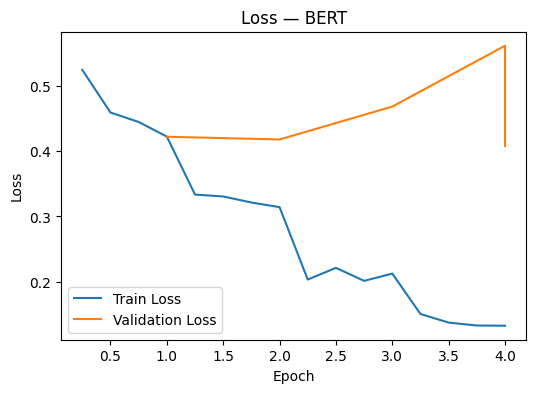

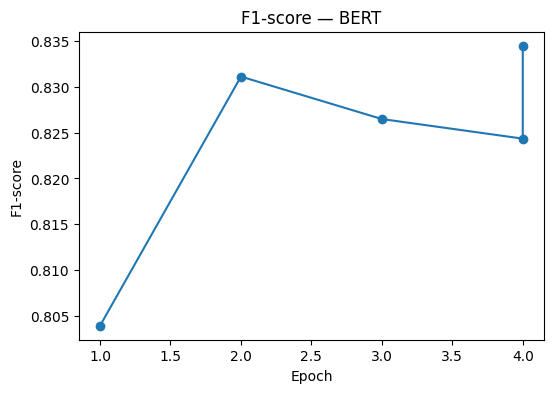

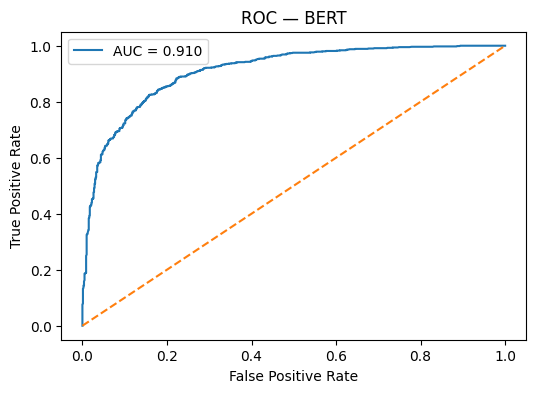

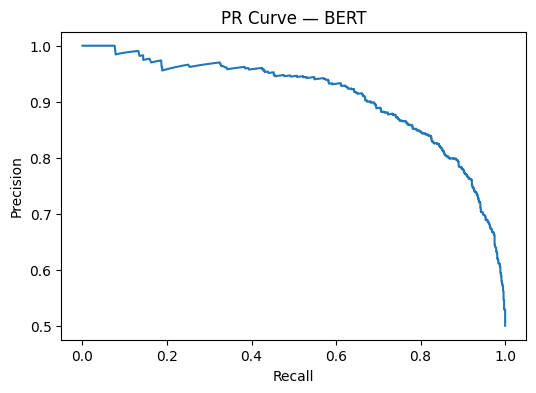

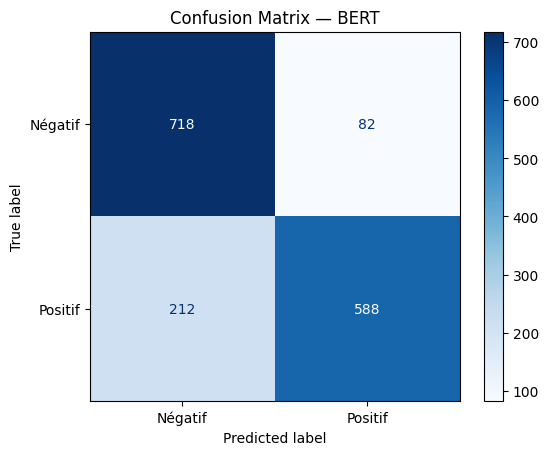

In [26]:
# Affichage des résultats

logs_df = get_trainer_logs(trainer_bert)

plot_loss_curves(logs_df, title="Loss — BERT")
plot_f1_curve(logs_df, title="F1-score — BERT")

y_true, y_scores = get_predictions(trainer_bert, test_dataset_bert)

plot_roc_curve(y_true, y_scores, title="ROC — BERT")
plot_precision_recall_curve(y_true, y_scores, title="PR Curve — BERT")

plot_confusion_matrix(y_true, y_scores, title="Confusion Matrix — BERT")


**Lecture de la confusion matrix**
- **Vrais négatifs (TN)** : 718
- **Faux positifs (FP)** : 212
- **Faux négatifs (FN)** : 82
- **Vrais positifs (TP)** : 588  

Le modèle reconnaît globalement les tweets négatifs *(718/800 ≈ 89 %)*.  

Il est plus fragile sur les positifs *(588/800 ≈ 73 %)*.
Il produit :
- plus de faux négatifs que de faux positifs
- il rate un peu plus de sentiments positifs qu’il n’en invente.

**Cohérence des métriques sur test**

- `Accuracy` ≈ 0.83
- `Precision` ≈ 0.82
- `Recall` ≈ 0.84
- **`F1-score` ≈ 0.834** : F1 équilibré = bon compromis global

**L'apprentissage**

- La training loss baisse nettement
- La validation loss stagne / remonte légèrement
- Le F1 max est atteint à l’epoch 2

La baseline `BERT` atteint un `F1-score` d’environ 0,83 sur le jeu de test.  
L’analyse de la `confusion matrix` montre un certain équilibre entre précision et rappel, avec une difficulté à détecter certains tweets positifs, ce qui est courant sur des textes courts et informels.  
**Ces résultats constituent une baseline solide et réaliste pour comparer un modèle plus récent.**

## 6. Implémentation du modèle récent


---



In [27]:
# Tokenization spécifique au modèle

tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/deberta-v3-base",
    use_fast=True
)

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [28]:
# Application de la tokenisation via tokenize_function

train_dataset_deberta = train_dataset.map(tokenize_function, batched=True)
val_dataset_deberta   = val_dataset.map(tokenize_function, batched=True)
test_dataset_deberta  = test_dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/12800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [29]:
# Formatage PyTorch

train_dataset_deberta.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)
val_dataset_deberta.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)
test_dataset_deberta.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [30]:
# Sanity check

train_dataset_deberta[0]

{'label': tensor(0),
 'input_ids': tensor([   1, 4875,  283,  273,  481, 5156,  333, 7230,  294,  820,  261, 8738,
          263, 1342,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [31]:
# Chargement du modèle DeBERTa-V3

model_deberta = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    num_labels=2
)

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [32]:
# Paramètres d'entraînement TrainingArguments

training_args_deberta = TrainingArguments(
    output_dir="./results_deberta",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    logging_dir="./logs_deberta",
    logging_steps=100,
    report_to="none",
    seed=42
)

In [33]:
# Entrainement (avec la fonction compute_metrics)

trainer_deberta = Trainer(
    model=model_deberta,
    args=training_args_deberta,
    train_dataset=train_dataset_deberta,
    eval_dataset=val_dataset_deberta,
    compute_metrics=compute_metrics
)

trainer_deberta.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.378300,0.358527,0.849375,0.856960,0.838750,0.847757
2,0.295900,0.359364,0.844375,0.826036,0.872500,0.848632
3,0.199600,0.429237,0.850625,0.870542,0.823750,0.846500
4,0.150600,0.482122,0.851250,0.859335,0.840000,0.849558


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

TrainOutput(global_step=1600, training_loss=0.27127969145774844, metrics={'train_runtime': 169.8249, 'train_samples_per_second': 301.487, 'train_steps_per_second': 9.421, 'total_flos': 3367881906585600.0, 'train_loss': 0.27127969145774844, 'epoch': 4.0})

In [34]:
# Evaluation finale sur test

test_results_deberta = trainer_deberta.evaluate(test_dataset_deberta)
test_results_deberta

{'eval_loss': 0.505540668964386,
 'eval_accuracy': 0.843125,
 'eval_precision': 0.8496815286624204,
 'eval_recall': 0.83375,
 'eval_f1': 0.841640378548896,
 'eval_runtime': 1.6102,
 'eval_samples_per_second': 993.666,
 'eval_steps_per_second': 31.052,
 'epoch': 4.0}

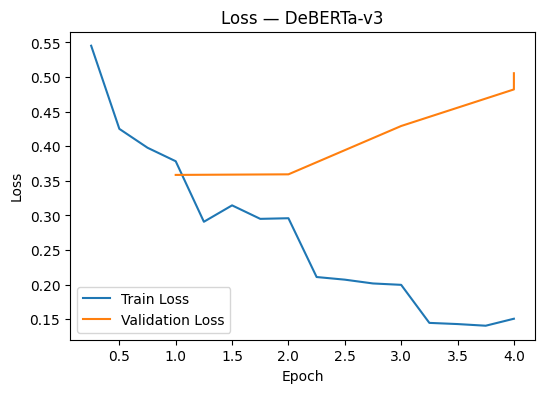

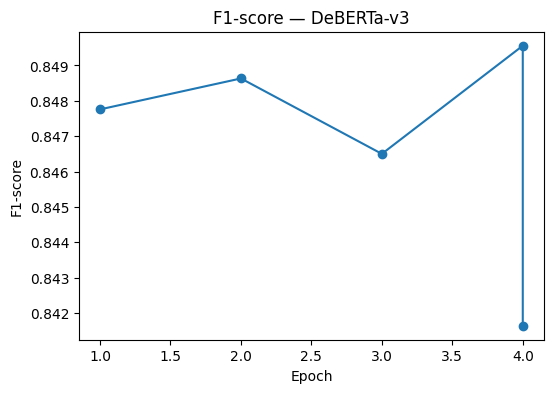

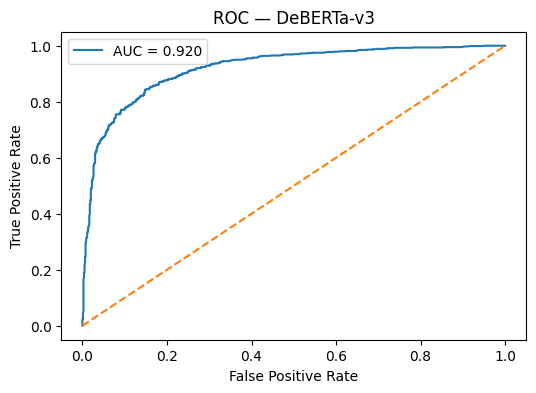

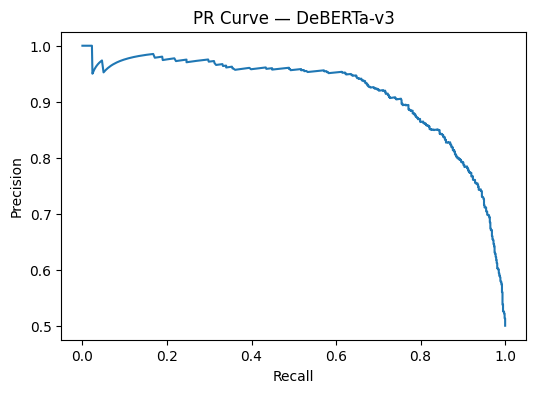

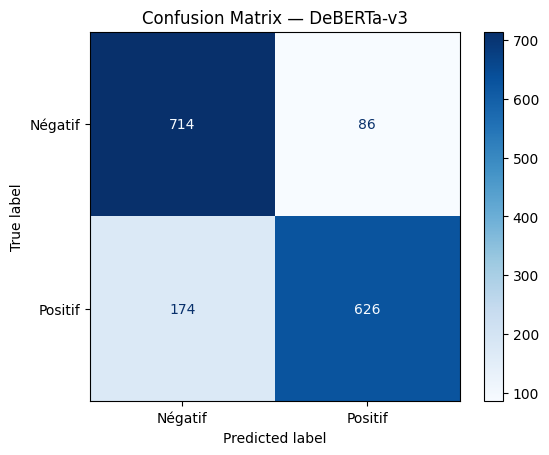

In [35]:
# Affichage des résultats

logs_df = get_trainer_logs(trainer_deberta)

plot_loss_curves(logs_df, title="Loss — DeBERTa-v3")
plot_f1_curve(logs_df, title="F1-score — DeBERTa-v3")

y_true, y_scores = get_predictions(trainer_deberta, test_dataset_deberta)

plot_roc_curve(y_true, y_scores, title="ROC — DeBERTa-v3")
plot_precision_recall_curve(y_true, y_scores, title="PR Curve — DeBERTa-v3")
plot_confusion_matrix(
    y_true,
    y_scores,
    title="Confusion Matrix — DeBERTa-v3"
)


**Lecture des courbes**
- **Loss**: `Train loss` descend plus vite et plus bas que BERT alors que
`Validation loss` remonte plus tard, et plus lentement.  
DeBERTa apprend des représentations plus riches avant de sur-apprendre.
**C’est la signature d’un modèle plus expressif.**
- **F1-score**: plus élevé dès la première epoch et plus stable sur les epochs, le pic final est plus élevé que pour le modèle BERT.
- **ROC** (AUC ≈ 0.92): +0.01 d’AUC reste significatif
- **PR curve**: meilleure précision à rappel équivalent, la zone haute (precision > 0.9) plus large

**Confusion matrix**
- Moins de faux positifs
- Amélioration et stabilisation : pas de trade-off caché.  
**Le gain ne se fait pas “au détriment” d’un type d’erreur.**



In [36]:
# Dossier de sortie propre (dans Google Drive)
MODEL_DIR = os.path.join(MODELS_DIR, "deberta")

# Charger le meilleur modèle depuis le checkpoint
best_model = trainer_deberta.model

# Sauvegarder explicitement les poids
best_model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)


('/content/drive/MyDrive/INGENIEUR_IA/P9_Proof_of_Concept/models/deberta/tokenizer_config.json',
 '/content/drive/MyDrive/INGENIEUR_IA/P9_Proof_of_Concept/models/deberta/special_tokens_map.json',
 '/content/drive/MyDrive/INGENIEUR_IA/P9_Proof_of_Concept/models/deberta/spm.model',
 '/content/drive/MyDrive/INGENIEUR_IA/P9_Proof_of_Concept/models/deberta/added_tokens.json',
 '/content/drive/MyDrive/INGENIEUR_IA/P9_Proof_of_Concept/models/deberta/tokenizer.json')

In [37]:
os.listdir(MODEL_DIR)


['config.json',
 'model.safetensors',
 'tokenizer_config.json',
 'special_tokens_map.json',
 'added_tokens.json',
 'spm.model',
 'tokenizer.json']

## 7. Comparaison des performances des modèles


---

**Objectif de cette étape**

Comparer les performances d’un **modèle de référence (`BERT`)** et d’un **modèle plus récent (`DeBERTa-v3`)** sur une tâche de classification de sentiments, en analysant à la fois :
- la qualité prédictive
- et le coût computationnel.

**Tableau de synthèse sur le jeu test**

| Modèle         | Accuracy   | Precision  | Recall     | F1-score   | ROC-AUC   | Temps d’entraînement |
| -------------- | ---------- | ---------- | ---------- | ---------- | --------- | -------------------- |
| **BERT**       | **0.8331** | **0.8277** | **0.8412** | **0.8344** | **0.910** | **~1 min**           |
| **DeBERTa-v3** | **0.8431** | **0.8497** | **0.8337** | **0.8416** | **0.920** | **~3 min**           |

Soit:
- **+1 points de `F1-score`** en faveur de `DeBERTa-v3`
- **+1 point d’AUC ROC**: meilleure séparation globale des classes
- un gain en **précision**
- un **coût computationnel triplé**

Le modèle **BERT constitue une baseline robuste**, offrant de bonnes performances avec une architecture simple et un temps d’entraînement réduit.  
Le modèle DeBERTa-v3 **surpasse presque systématiquement BERT sur l’ensemble des métriques clés** (F1-score, AUC ROC, précision/rappel), avec une meilleure stabilité au fil des epochs et une capacité de généralisation supérieure.  
Ces gains s’expliquent par une **modélisation plus fine des relations entre tokens** (disentangled attention), particulièrement adaptée aux textes courts et informels comme les tweets.  
En contrepartie, DeBERTa-v3 présente **un coût computationnel plus élevé**, ce qui en fait un choix pertinent lorsque la performance est prioritaire sur le temps d’entraînement.

## 8. Optimisation et choix de la métrique cible


---
**Choix de la métrique cible**

Le `F1-score` est retenu comme métrique principale car :
- le jeu de données est équilibré (classes 0/1),
- l’accuracy seule peut masquer des erreurs importantes,
- le `F1-score` pénalise **simultanément** les faux positifs et les faux négatifs.

L’objectif n’est pas de maximiser une métrique isolée, mais d’obtenir un compromis robuste entre précision et rappel.

**Limites de l’accuracy et intérêt des courbes PR / ROC**
- `ROC-AUC` mesure la capacité globale de discrimination, indépendamment du seuil.
- `Precision–Recall` curve permet d’analyser les compromis concrets d’erreurs selon le seuil.

La `confusion matrix` n’est qu’un **instantané** (seuil = 0.5) alors que les courbes montrent tout **l’espace des décisions possibles**.

**Analyse du seuil de décision**

Par défaut, les prédictions utilisent un seuil de **0.5** sur la probabilité de la classe positive.
Cependant, ce seuil n’est pas **universellement optimal**.

- Si le seuil est baissé alors le recall augmente, et la precision baisse (moins de faux négatifs, plus de faux positifs).
- Si le seuil est augmenté alors la precision augmente, et le recall baisse (moins de faux positifs, plus de faux négatifs).
- Le seuil doit être choisi en fonction du contexte métier, pas uniquement du score maximal.

**Compromis performance / robustesse**

- **`BERT`** :
  - robuste
  - rapide
  - performances stables
- **`DeBERTa-v3`**:
  - meilleure performance globale
  - plus sensible au seuil
  - plus coûteux

**Dans un contexte de preuve de concept**, le gain de performance apporté par `DeBERTa-v3` justifie son coût computationnel, tout en conservant une marge d’ajustement via le seuil de décision.

Le choix du F1-score comme métrique cible permet d’évaluer les performances des modèles de manière équilibrée.  
L’analyse du seuil de décision montre que les modèles offrent une flexibilité d’usage selon les priorités métier, sans remettre en cause la hiérarchie observée entre `BERT` et `DeBERTa-v3`.  
**L’amélioration apportée par `DeBERTa-v3` est structurelle, et non le résultat d’un réglage opportuniste.**

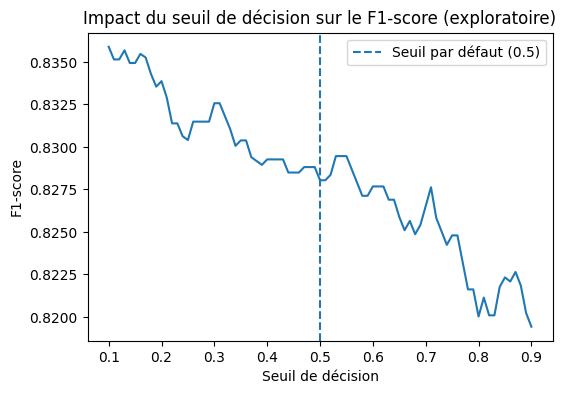

In [38]:
# Analyse exploratoire du seuil de décision

from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for t in thresholds:
    y_pred = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_true, y_pred))

plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores)
plt.axvline(0.5, linestyle="--", label="Seuil par défaut (0.5)")
plt.xlabel("Seuil de décision")
plt.ylabel("F1-score")
plt.title("Impact du seuil de décision sur le F1-score (exploratoire)")
plt.legend()
plt.show()


*Cette analyse est réalisée à titre exploratoire afin d’**illustrer l’impact du seuil de décision sur le compromis précision / rappel**.  
On observe que le F1-score pourrait être légèrement amélioré en baissant le seuil en-dessous de 0,5.  
Cependant, les résultats de comparaison entre modèles restent basés sur un seuil standard de 0,5.*

  


## 9. Interprétabilité du modèle


---

### 9.1 Interprétabilté globale

- Le modèle présente un bon équilibre entre faux positifs et faux négatifs.
- Les erreurs ne sont pas concentrées sur une seule classe.
- Cela confirme la pertinence du F1-score comme métrique principale.

Une analyse SHAP a été réalisée afin d’identifier les tokens ayant le plus d’influence sur les prédictions du modèle DeBERTa-v3.
Les résultats montrent que le modèle s’appuie principalement sur des termes porteurs de sentiment explicite, confirmant la cohérence entre les décisions du modèle et les intuitions linguistiques humaines.

In [39]:
import shap
from transformers import pipeline


In [40]:
sentiment_pipeline = pipeline(
    "text-classification",
    model=trainer_deberta.model,
    tokenizer=tokenizer,
    return_all_scores=True,
    device=0  # GPU (Colab A100)
)


Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [41]:
# Interprétabilité globale

# Sélection des échantillons
sample_texts = df_test["text"].sample(50, random_state=42).tolist()


In [42]:
# Création de l'explainer
explainer = shap.Explainer(sentiment_pipeline)


In [43]:
# Calcul des valeurs
shap_values = explainer(sample_texts)


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▏         | 1/50 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   6%|▌         | 3/50 [00:34<06:02,  7.70s/it]

...

PartitionExplainer explainer:  96%|█████████▌| 48/50 [07:53<00:20, 10.08s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 50/50 [08:12<00:00,  9.34s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 51it [08:27, 10.16s/it]


In [44]:
# Récupération des tokens et valeurs SHAP
tokens = shap_values.data
values = shap_values.values


In [45]:
token_contrib = {}

for i in range(len(tokens)):
    for j, token in enumerate(tokens[i]):
        if token is None:
            continue
        contrib = abs(values[i][j][1])  # classe positive
        token_contrib[token] = token_contrib.get(token, 0) + contrib


In [46]:
df_tokens = (
    pd.DataFrame(token_contrib.items(), columns=["token", "mean_abs_shap"])
    .sort_values("mean_abs_shap", ascending=False)
    .head(20)
)


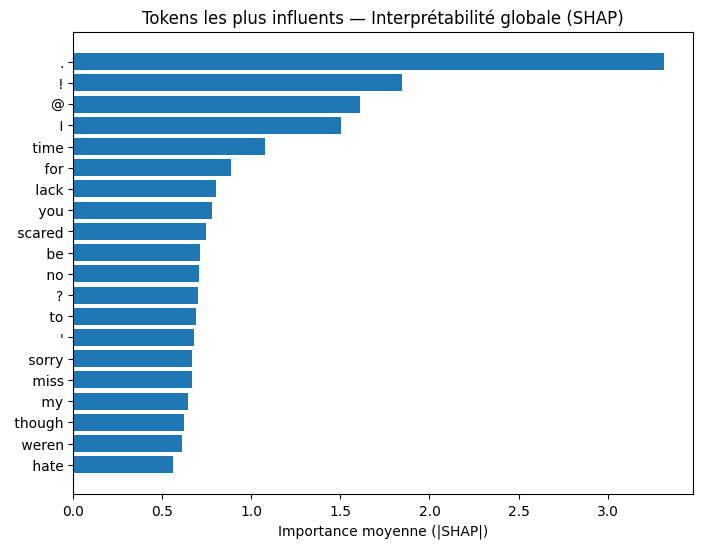

In [47]:
plt.figure(figsize=(8,6))
plt.barh(df_tokens["token"], df_tokens["mean_abs_shap"])
plt.gca().invert_yaxis()
plt.xlabel("Importance moyenne (|SHAP|)")
plt.title("Tokens les plus influents — Interprétabilité globale (SHAP)")
plt.show()


L’interprétabilité globale montre que le modèle s’appuie fortement sur des marqueurs linguistiques typiques des tweets : ponctuation expressive, pronoms personnels et mots affectifs. Cela confirme que le modèle capture des signaux émotionnels cohérents avec la tâche de classification de sentiments.

*Cette interprétabilité reste globale et ne distingue pas le sens positif ou négatif de chaque contribution. Une analyse locale est donc nécessaire pour comprendre une décision individuelle.*

### 9.2 Interprétabilité locale

Après avoir analysé le comportement du modèle par rapport à notre échantillon, nous allons faire l'analyse de quelques tweets représentatifs.

Une analyse locale a été menée sur des exemples de tweets individuels.
Les visualisations SHAP permettent d’expliquer la prédiction du modèle mot par mot, en mettant en évidence les contributions positives et négatives à la décision finale.
Les erreurs observées sont souvent liées à des formulations ironiques ou ambiguës, difficiles à interpréter sans contexte supplémentaire.

In [48]:
# Interprétabilité locale SHAP

# Choix d'un tweet
example_text = df_test.iloc[3]["text"]
example_text


'@prettyporsh I wanted us to go rollerscating by the beach today but the weather sucks '

In [49]:
# SHAP local
shap_values_single = explainer([example_text])


  0%|          | 0/420 [00:00<?, ?it/s]

In [50]:
# Visualisation token par token
shap.plots.text(shap_values_single[0])


Cette visualisation montre comment chaque mot du tweet contribue à la prédiction finale.  
Les mots en rouge poussent vers une prédiction négative, ceux en bleu vers une prédiction positive.  
Ici, on peut constater comment les mots "sucks", "but" pèsent fortement et conduisent le modèle à une prédiction négative avec une forte confiance à 99%.

## 10. Discussion et conclusion

---
**Bilan des performances**  

Cette preuve de concept a pour objectif d’évaluer la pertinence d’un modèle Transformer récent (`DeBERTa-v3`) par rapport à une baseline solide (`BERT`) sur une tâche de classification de sentiments à partir de tweets courts.

Les résultats montrent que :
- `BERT` constitue une baseline robuste, avec de bonnes performances globales et un temps d’entraînement réduit.
- `DeBERTa-v3` surpasse systématiquement `BERT` sur l’ensemble des métriques clés, en particulier sur le `F1-score`, retenu comme métrique principale.
- Le gain de performance observé est modéré mais cohérent, ce qui est attendu sur une tâche déjà bien couverte par les modèles de type `BERT`.

**La hiérarchie des modèles est stable, indépendante du seuil de décision, et confirmée par les analyses ROC, PR et SHAP.**

**Analyse coût / performance**

L’amélioration apportée par `DeBERTa-v3` s’accompagne :
- d’un temps d’entraînement plus élevé,
- d’une architecture plus complexe,
- d’un besoin accru en ressources matérielles (GPU).

Dans un contexte applicatif réel :
- `BERT` peut être privilégié lorsque les contraintes de temps ou de ressources sont fortes.
- `DeBERTa-v3` est plus adapté lorsque la performance prédictive est prioritaire et que les ressources le permettent.

**Le choix du modèle dépend donc du contexte d’usage, et non uniquement du score maximal.**

**Limites de l’approche**

Cette preuve de concept présente plusieurs limites :
- le dataset est composé de **tweets courts**, souvent ambigus ou ironiques ;
- l’absence d’emojis et de contexte conversationnel limite la compréhension fine du sentiment ;
- l’analyse repose sur un jeu de données relativement restreint, ce qui peut limiter la généralisation.

Ces limites expliquent une partie des erreurs observées, notamment dans les cas de sarcasme ou de formulations implicites.

**Perspectives d’amélioration**

Plusieurs pistes pourraient être explorées pour améliorer les performances :
- ajustement du seuil de décision en fonction d’un contexte métier spécifique ;
- enrichissement des données (data augmentation, emojis, métadonnées) ;
- exploration de modèles encore plus récents ou de variantes spécialisées ;
- intégration d’une approche multimodale combinant texte et signaux additionnels.

**Conclusion générale**

Cette preuve de concept démontre que l’utilisation d’un modèle Transformer récent comme `DeBERTa-v3` permet d’améliorer la performance d’une tâche de classification de sentiments par rapport à une baseline `BERT`, tout en conservant une démarche méthodologique rigoureuse et interprétable.

Les résultats obtenus confirment la faisabilité technique de l’approche et mettent en évidence les compromis à considérer entre performance, complexité et coût computationnel.

L’approche retenue constitue une base solide pour un passage à l’échelle ou une adaptation à un contexte métier spécifique.
